In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")
data.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
data.shape

(246945, 378)

In [9]:
data.info

<bound method DataFrame.info of                       diseases  anxiety and nervousness  depression  \
0               panic disorder                        1           0   
1               panic disorder                        0           0   
2               panic disorder                        1           1   
3               panic disorder                        1           0   
4               panic disorder                        1           1   
...                        ...                      ...         ...   
246940  open wound of the nose                        0           0   
246941  open wound of the nose                        0           0   
246942  open wound of the nose                        0           0   
246943  open wound of the nose                        0           0   
246944  open wound of the nose                        0           0   

        shortness of breath  depressive or psychotic symptoms  \
0                         1                       

In [10]:
data.isnull().sum().sum()

np.int64(0)

In [11]:
data.duplicated().sum()

np.int64(57298)

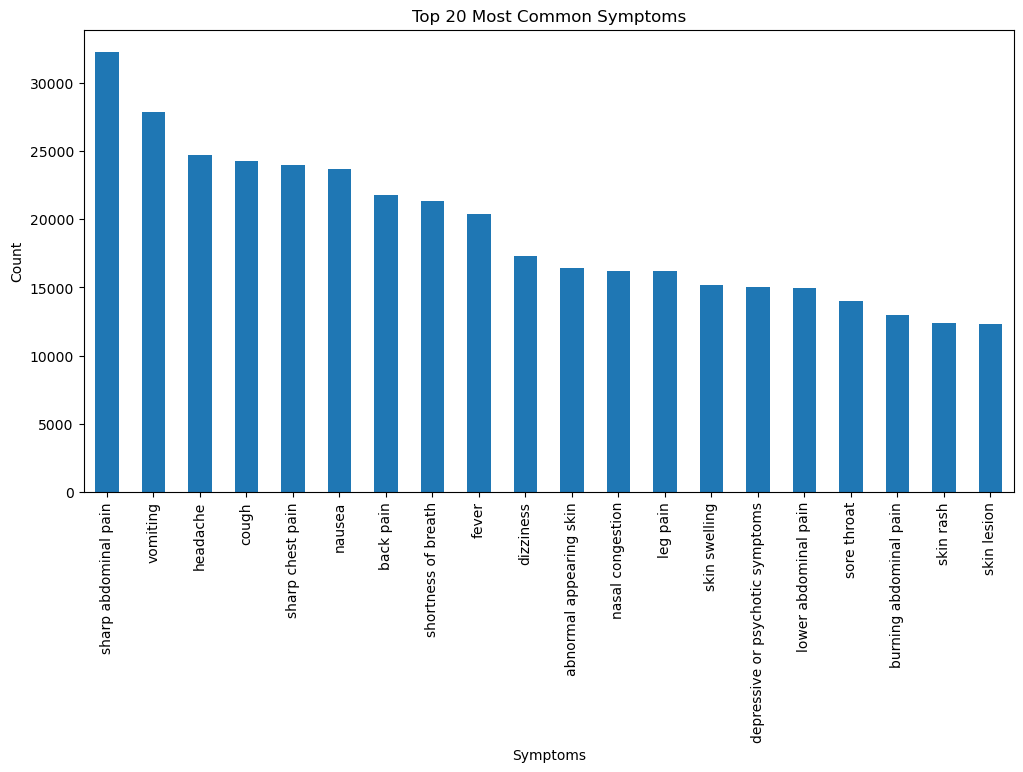

In [12]:
symptom_counts = data.drop("diseases", axis=1).sum()

top_symptoms = symptom_counts.sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))

top_symptoms.plot(kind='bar')

plt.title("Top 20 Most Common Symptoms")

plt.xlabel("Symptoms")
plt.ylabel("Count")

plt.show()

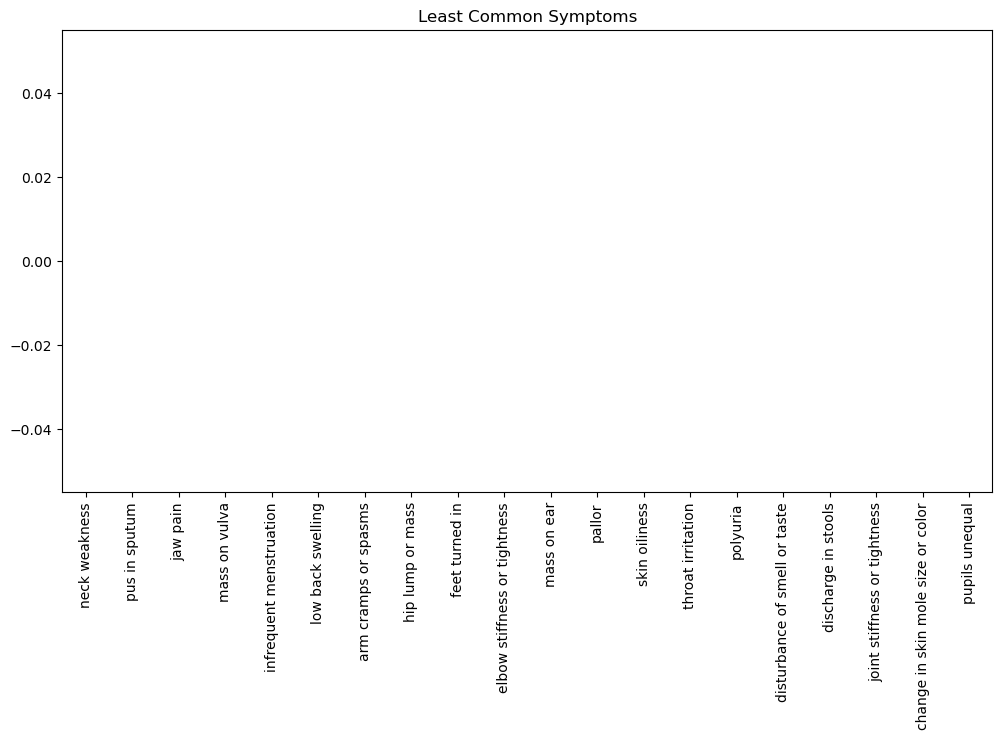

In [13]:
rare_symptoms = symptom_counts.sort_values().head(20)

plt.figure(figsize=(12,6))

rare_symptoms.plot(kind='bar')

plt.title("Least Common Symptoms")

plt.show()

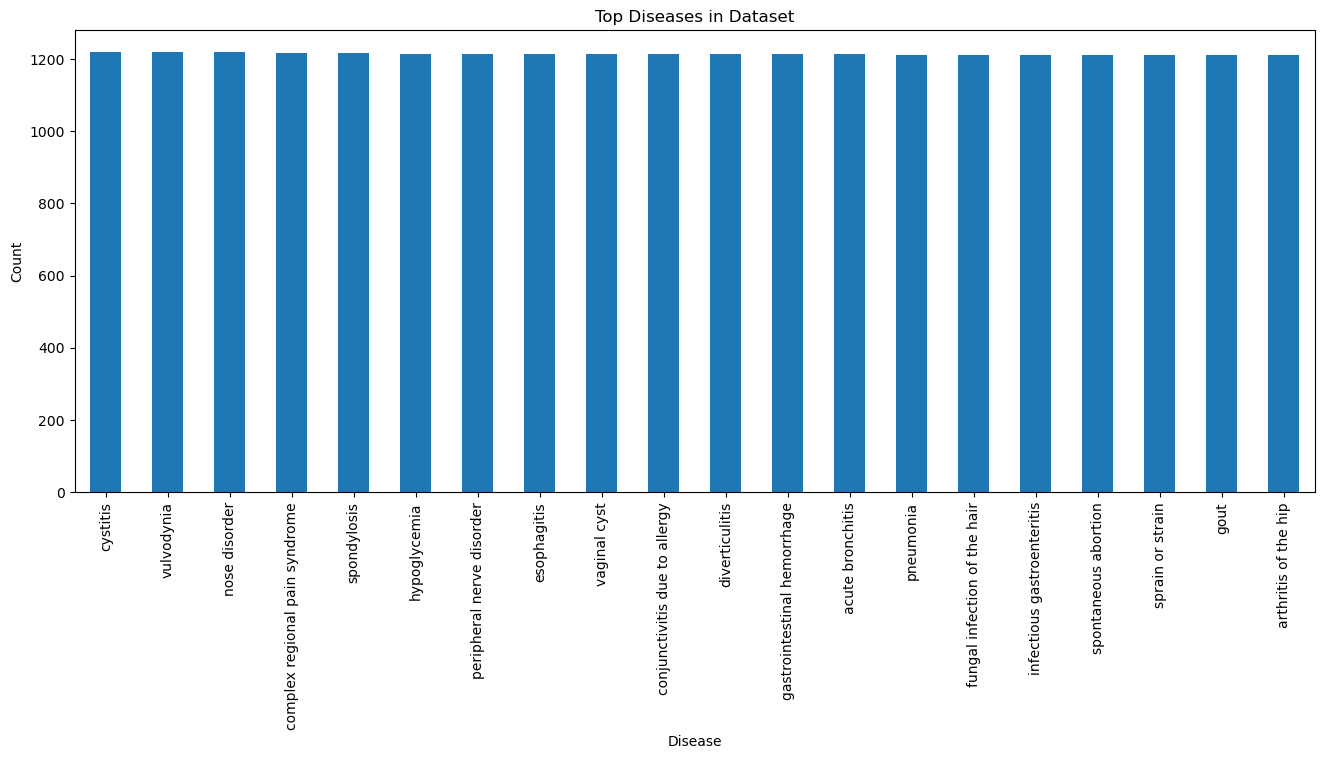

In [14]:
plt.figure(figsize=(16,6))

data['diseases'].value_counts().head(20).plot(kind='bar')

plt.title("Top Diseases in Dataset")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

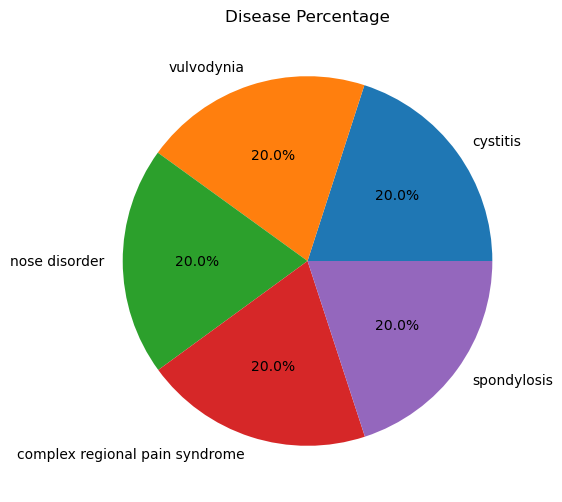

In [15]:
data['diseases'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Disease Percentage")

plt.ylabel("")

plt.show()

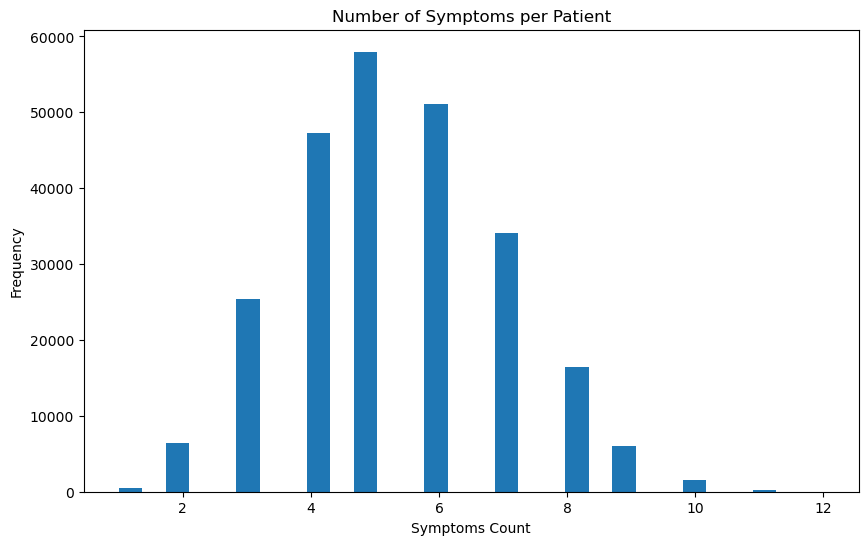

In [16]:
symptom_per_patient = data.drop("diseases", axis=1).sum(axis=1)

plt.figure(figsize=(10,6))

plt.hist(symptom_per_patient, bins=30)

plt.title("Number of Symptoms per Patient")

plt.xlabel("Symptoms Count")
plt.ylabel("Frequency")

plt.show()

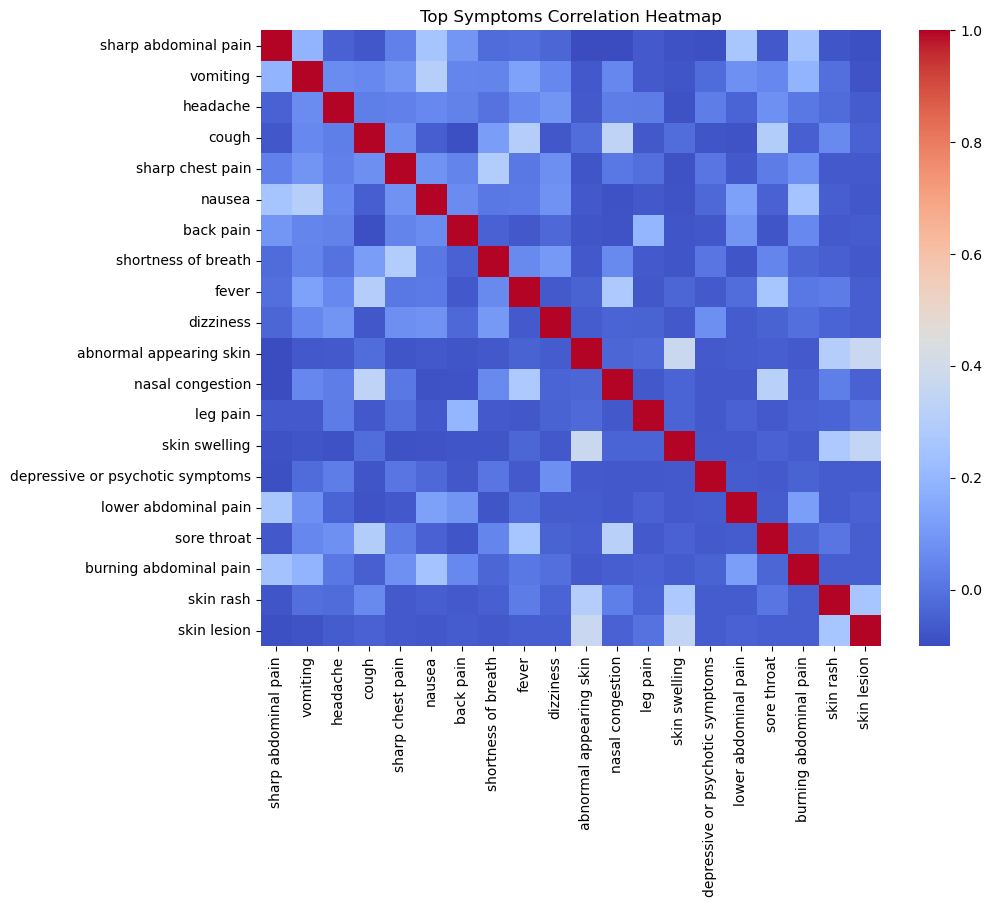

In [17]:
top_symptoms = data.drop("diseases", axis=1).sum().sort_values(ascending=False).head(20).index

sample = data[top_symptoms]

plt.figure(figsize=(10,8))

sns.heatmap(sample.corr(), cmap="coolwarm")

plt.title("Top Symptoms Correlation Heatmap")

plt.show()

In [18]:
data['diseases'].nunique()

773

In [19]:
data['diseases'].unique()

array(['panic disorder', 'vocal cord polyp', 'turner syndrome',
       'cryptorchidism', 'poisoning due to ethylene glycol',
       'atrophic vaginitis', 'fracture of the hand',
       'cellulitis or abscess of mouth', 'eye alignment disorder',
       'headache after lumbar puncture', 'pyloric stenosis',
       'salivary gland disorder', 'osteochondrosis', 'injury to the knee',
       'metabolic disorder', 'vaginitis', 'sick sinus syndrome',
       'tinnitus of unknown cause', 'glaucoma', 'eating disorder',
       'transient ischemic attack', 'pyelonephritis',
       'rotator cuff injury', 'chronic pain disorder',
       'problem during pregnancy', 'liver cancer', 'atelectasis',
       'injury to the hand', 'choledocholithiasis', 'injury to the hip',
       'cirrhosis', 'thoracic aortic aneurysm', 'subdural hemorrhage',
       'diabetic retinopathy', 'fibromyalgia', 'ischemia of the bowel',
       'fetal alcohol syndrome', 'peritonitis', 'injury to the abdomen',
       'acute pancreati

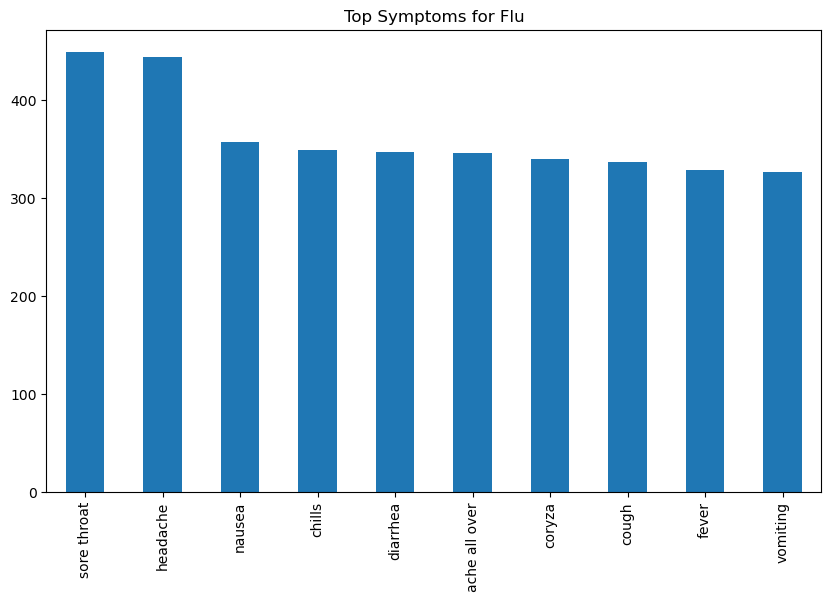

In [20]:
flu_data = data[data['diseases'] == 'flu']

flu_symptoms = flu_data.drop("diseases", axis=1).sum()

top_flu = flu_symptoms.sort_values(ascending=False).head(10)

top_flu.plot(kind='bar', figsize=(10,6))

plt.title("Top Symptoms for Flu")

plt.show()

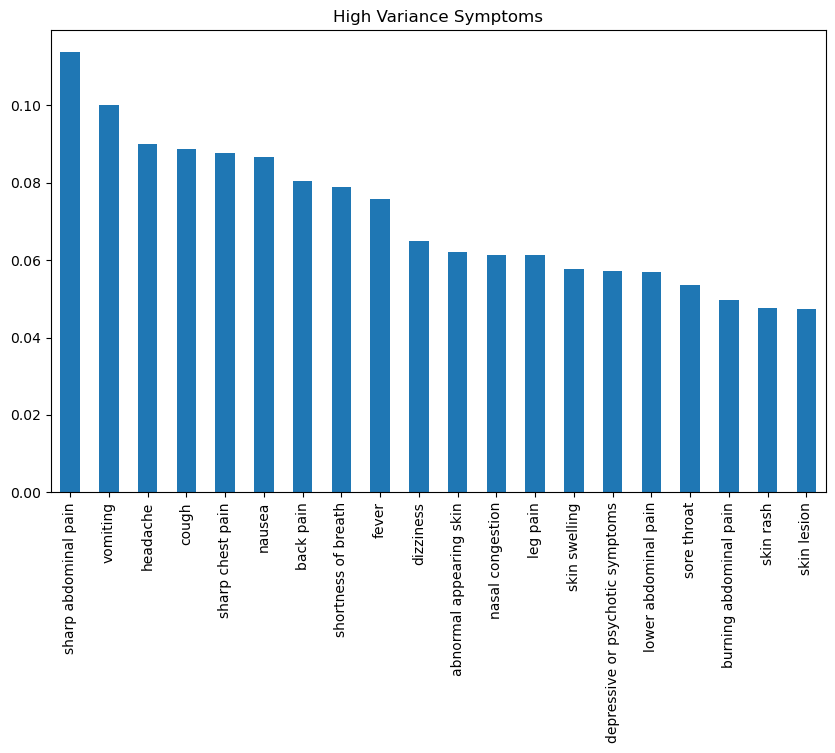

In [21]:
variance = data.drop("diseases", axis=1).var()

top_var = variance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))

top_var.plot(kind='bar')

plt.title("High Variance Symptoms")

plt.show()

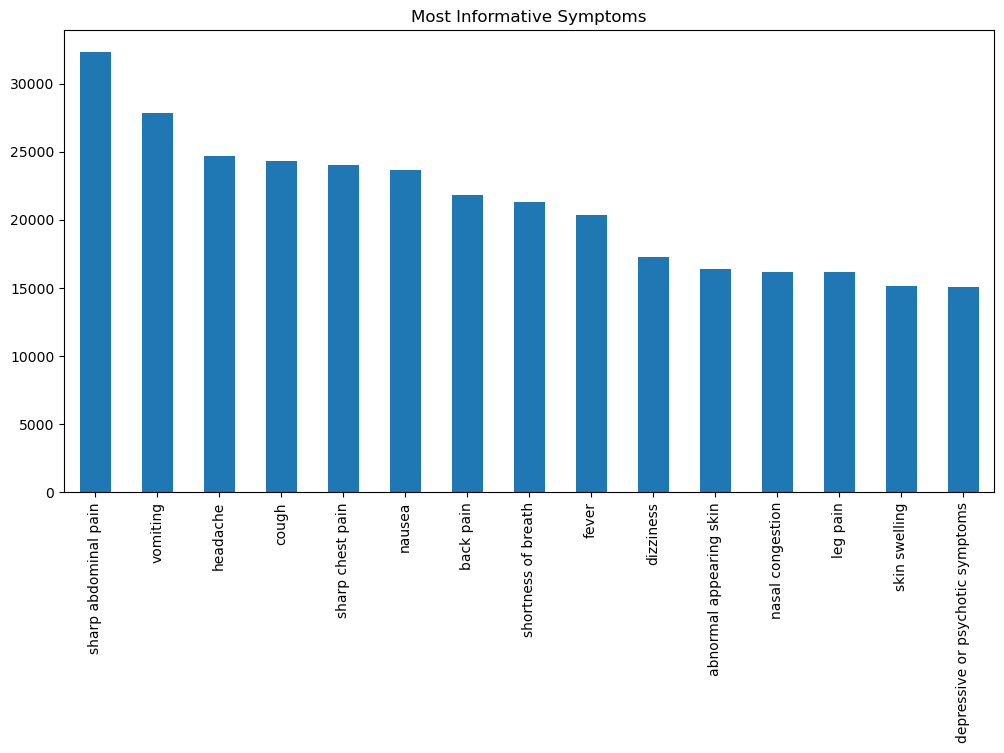

In [22]:
symptom_counts = data.drop("diseases", axis=1).sum()

important_symptoms = symptom_counts.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

important_symptoms.plot(kind='bar')

plt.title("Most Informative Symptoms")

plt.show()

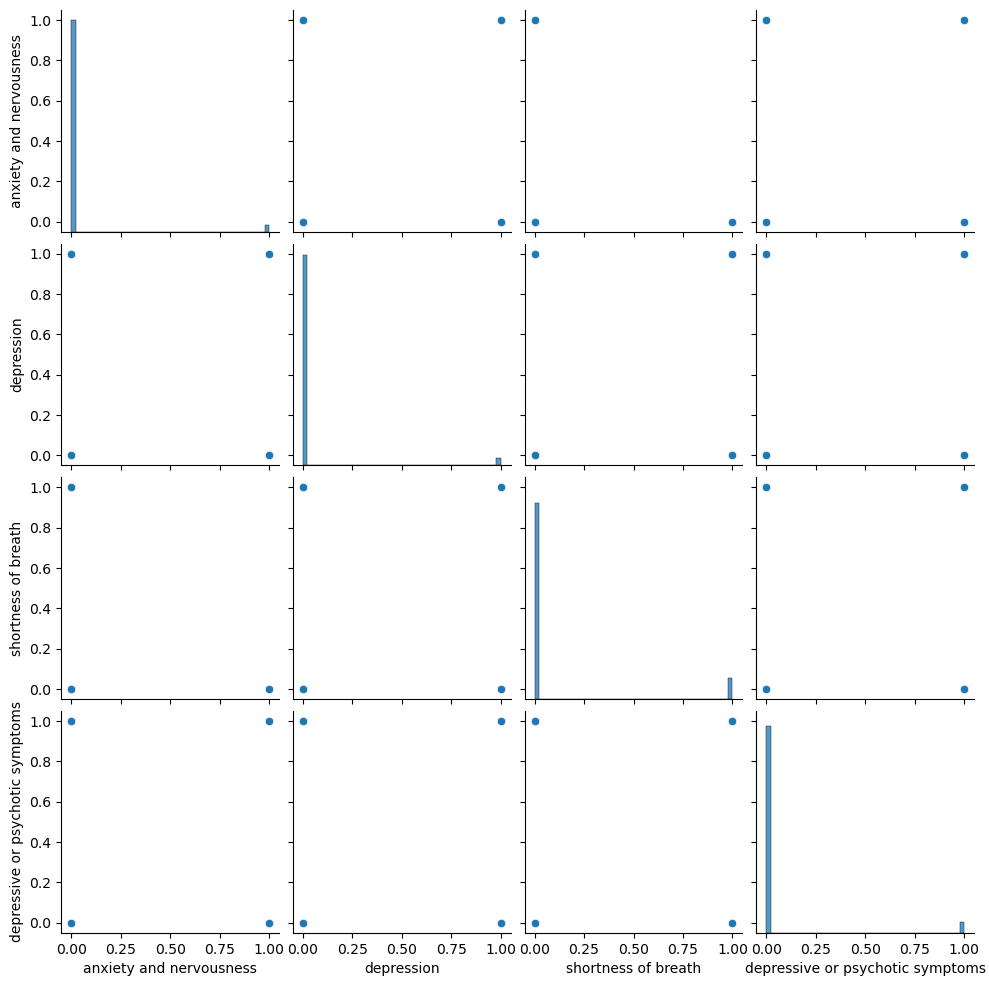

In [23]:
sample = data.sample(500)

sns.pairplot(sample.iloc[:, :5])

<Axes: xlabel='diseases'>

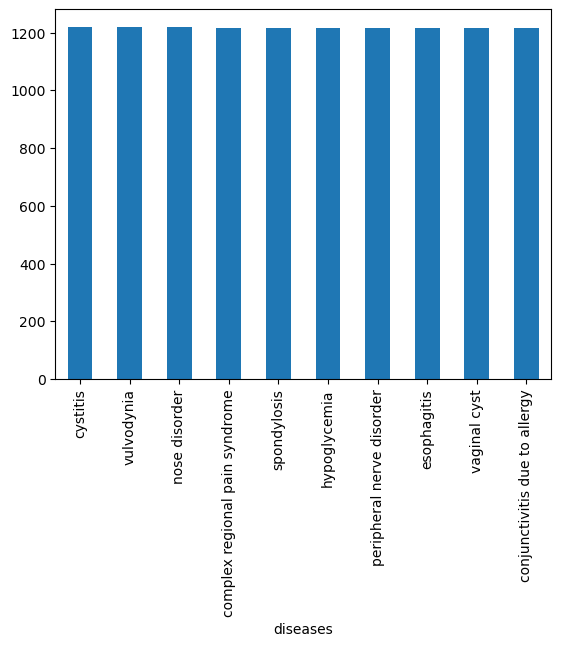

In [24]:
disease_freq = data['diseases'].value_counts()

disease_freq.head(10).plot(kind='bar')

In [25]:
sample_data = data.sample(20000, random_state=42)

In [26]:
X = sample_data.drop("diseases", axis=1)
y = sample_data["diseases"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()



In [33]:

model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.676


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

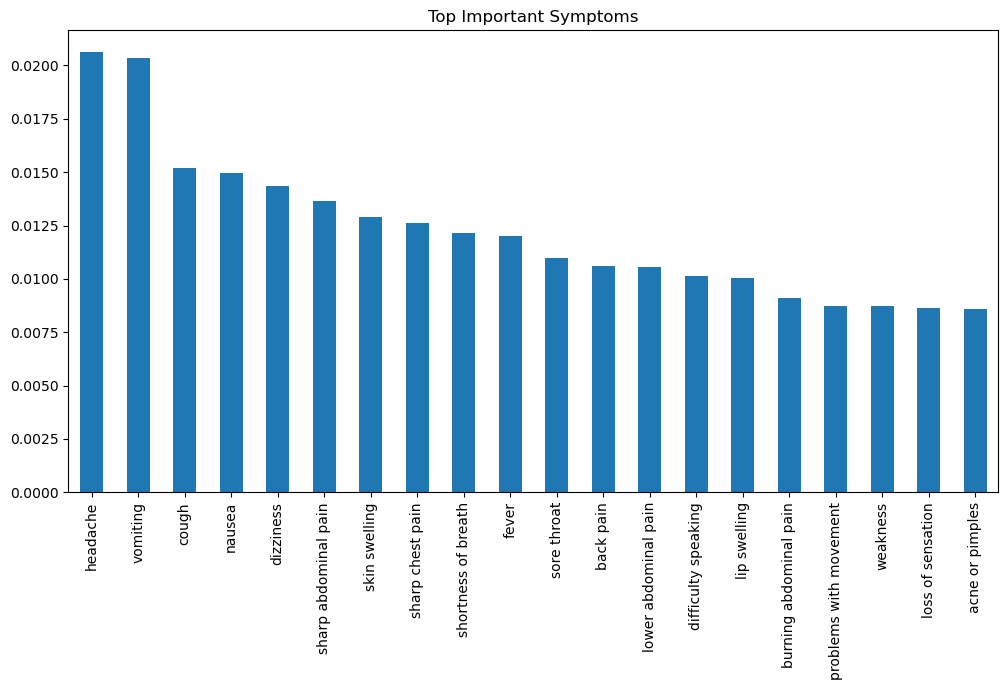

In [38]:
from sklearn.tree import plot_tree

importance = model.feature_importances_

features = X.columns

importance_df = pd.Series(importance, index=features)

top_features = importance_df.sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))

top_features.plot(kind='bar')

plt.title("Top Important Symptoms")

plt.show()

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

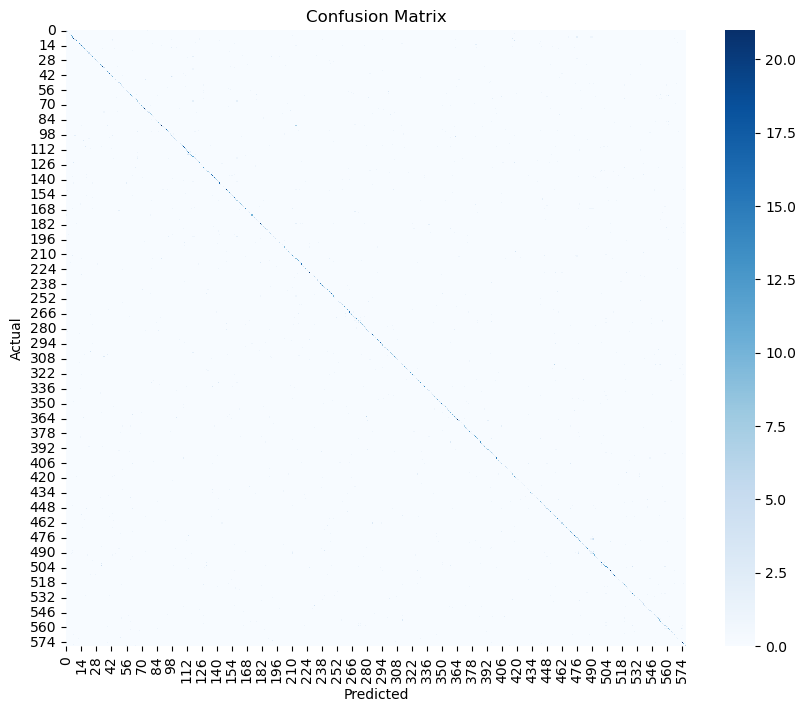

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

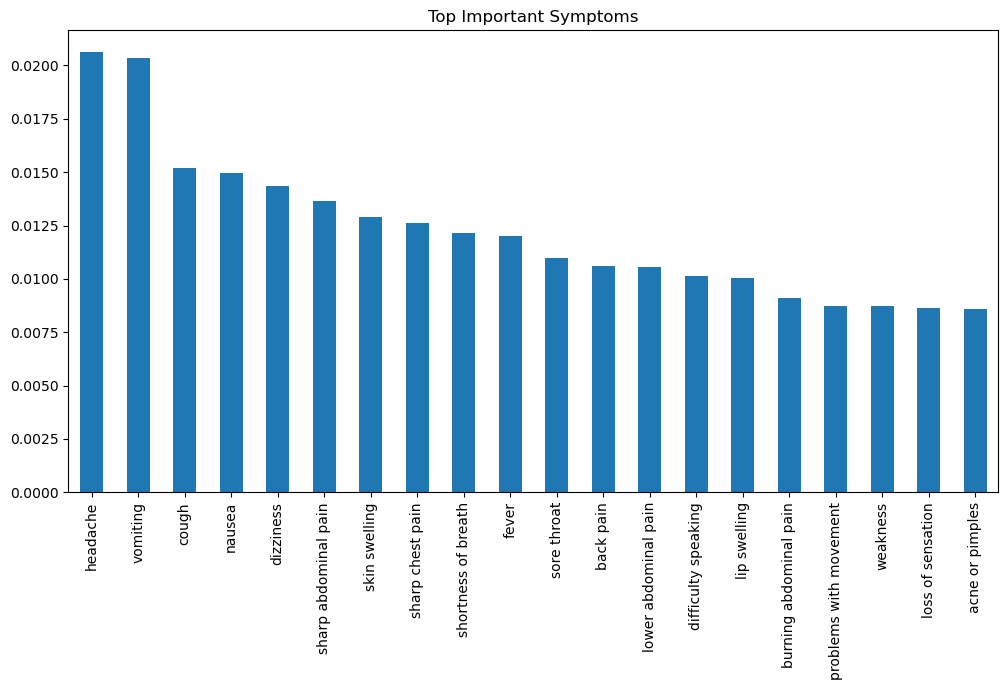

In [41]:
importance = model.feature_importances_

features = X.columns

importance_df = pd.Series(importance, index=features)

top_features = importance_df.sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))

top_features.plot(kind='bar')

plt.title("Top Important Symptoms")

plt.show()

In [59]:
data = data.drop_duplicates()

In [67]:
disease_counts = data['diseases'].value_counts()

valid_diseases = disease_counts[disease_counts >= 100].index

data = data[data['diseases'].isin(valid_diseases)]

In [68]:
X = data.drop("diseases", axis=1)
y = data["diseases"]

In [69]:
selector = SelectKBest(chi2, k=50)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred = model.predict(X_test)

In [73]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.12541815343443355


In [74]:
import pickle

pickle.dump(model, open("disease_model.pkl", "wb"))
pickle.dump(X.columns, open("symptom_names.pkl", "wb"))